In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

## Wczytanie zbioru GLASS
Dane dzielimy na:
- **X_glass** – cechy (zawartość różnych pierwiastków w szkle)
- **y_glass** – etykiety klas (typ szkła)

In [52]:
glass_repo = fetch_ucirepo(id=42)

X_glass = glass_repo.data.features
y_glass = glass_repo.data.targets

df_glass = pd.concat([X_glass, y_glass], axis=1)
df_glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Analiza zbioru i wizualizacja rozkładu danych

In [53]:
print(f"Number of rows: {len(df_glass)}")
print(f"Number of attributes: {len(X_glass.columns)}")
print(f"\nStatistics:")
print(df_glass.describe())

Number of rows: 214
Number of attributes: 9

Statistics:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe  Type_of_glass  
count  214.000000  214.000000  214.000000     214.000000  
mean     8.956963    0.175047    0.057009       2.780374  
std      1.423153    0.497219    0.0

Classes: [1 2 3 5 6 7]

Class distribution:
Type_of_glass
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_32376/1137795276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_glass, x='Type_of_glass', palette='tab10')


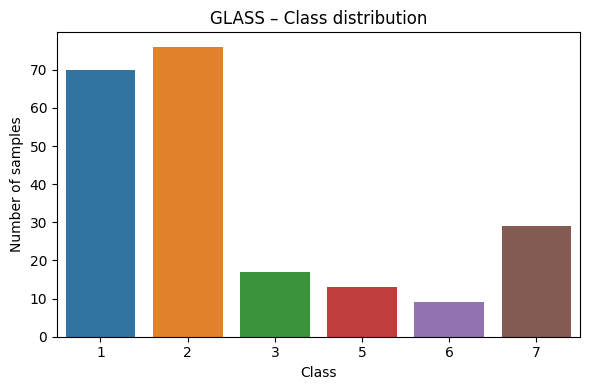

In [54]:
print(f"Classes: {df_glass['Type_of_glass'].unique()}")
print(f"\nClass distribution:")
print(df_glass['Type_of_glass'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_glass, x='Type_of_glass', palette='tab10')
plt.title('GLASS – Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

Klasy szkła reprezentowane w zbiorze to:
- 1 building_windows_float_processed
- 2 building_windows_non_float_processed
- 3 vehicle_windows_float_processed
- 4 vehicle_windows_non_float_processed (none in this database)
- 5 containers
- 6 tableware
- 7 headlamps

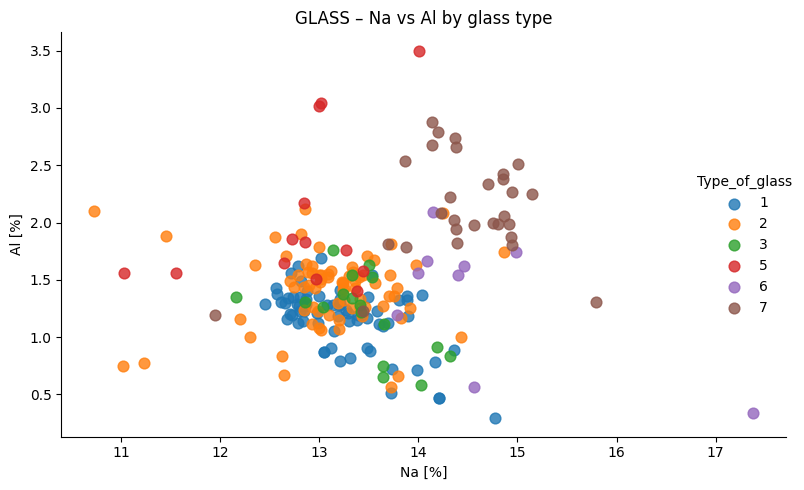

In [56]:
sns.lmplot(
    data=df_glass,
    x='Na',
    y='Al',
    hue='Type_of_glass',
    height=5,
    aspect=1.4,
    fit_reg=False,
    scatter_kws={'s': 60}
)
plt.title('GLASS – Na vs Al by glass type')
plt.xlabel('Na [%]')
plt.ylabel('Al [%]')
plt.tight_layout()
plt.show()

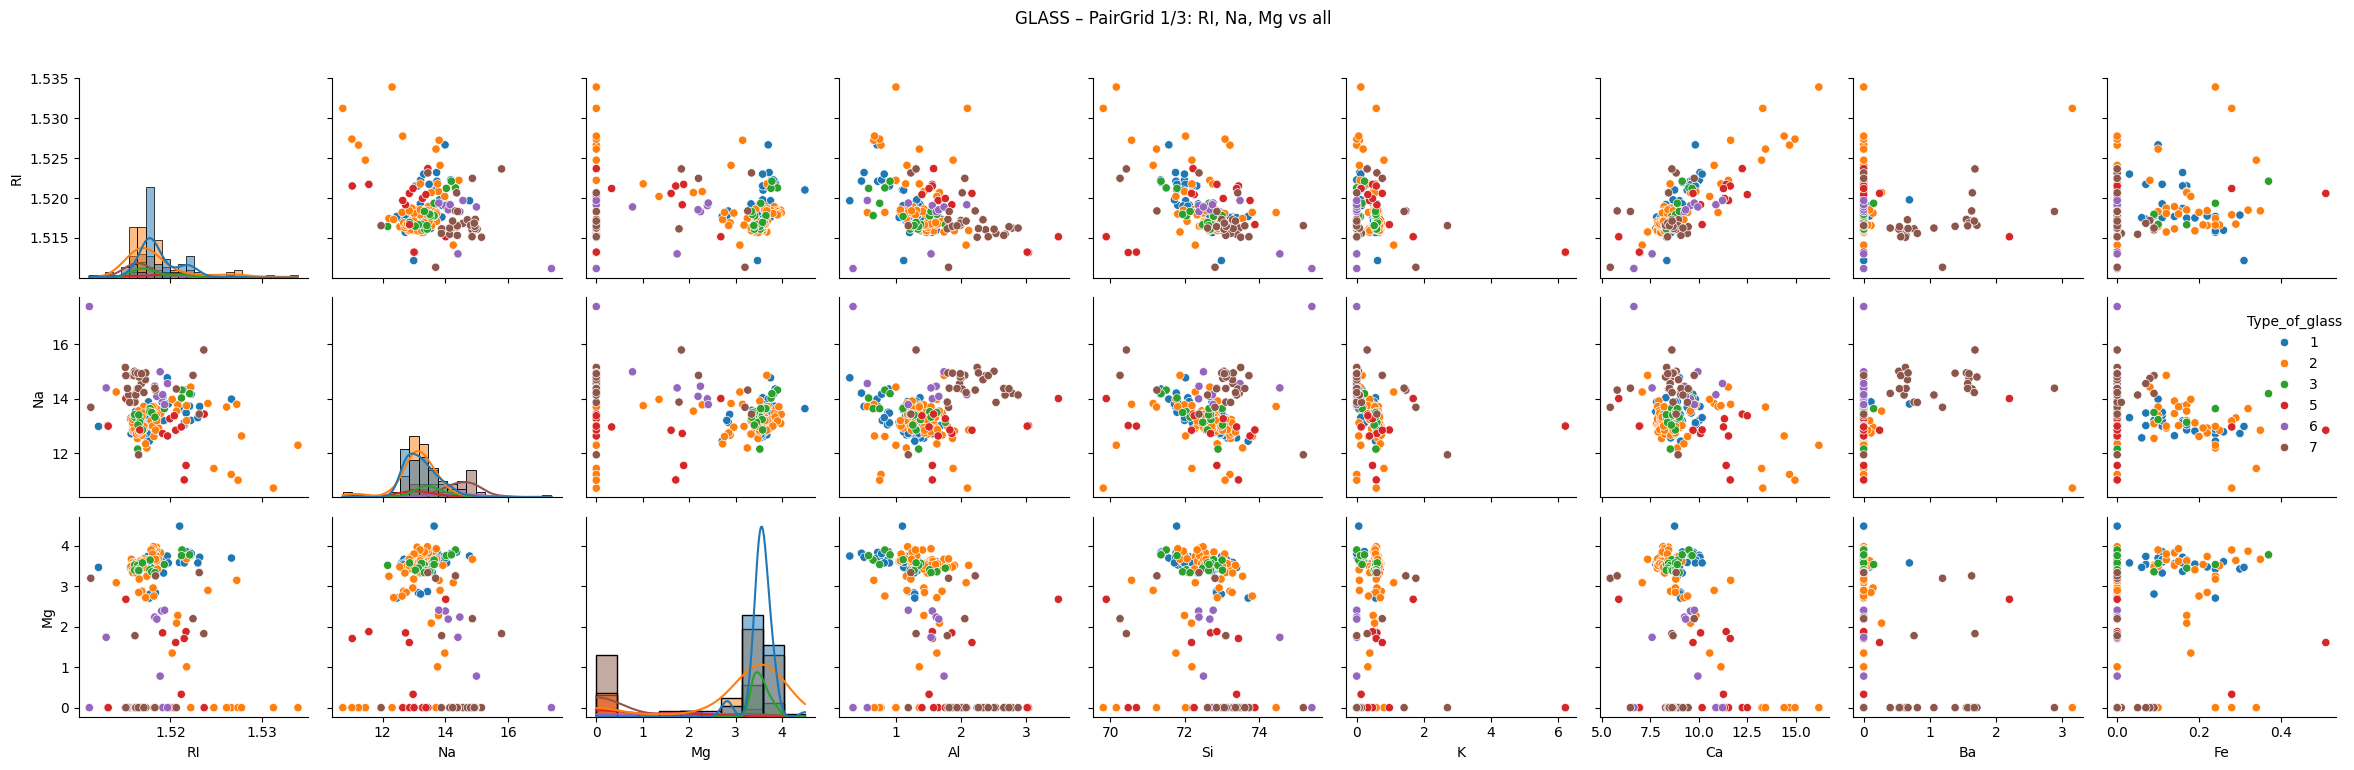

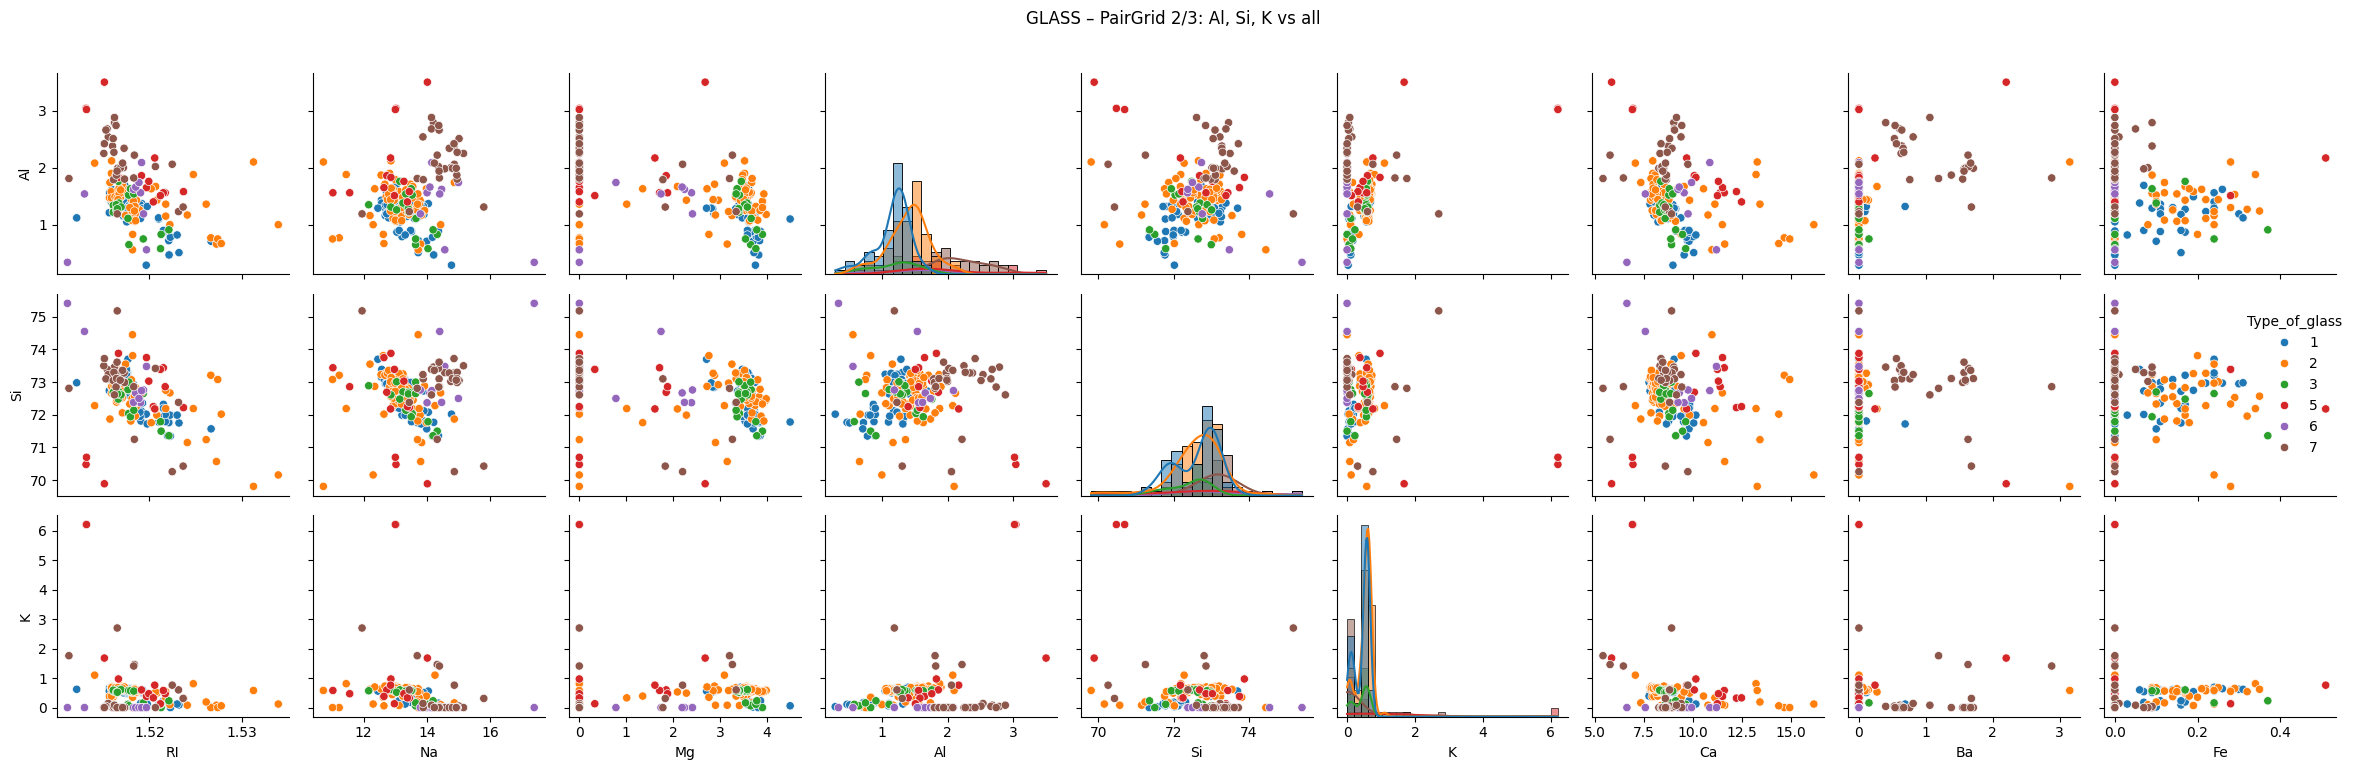

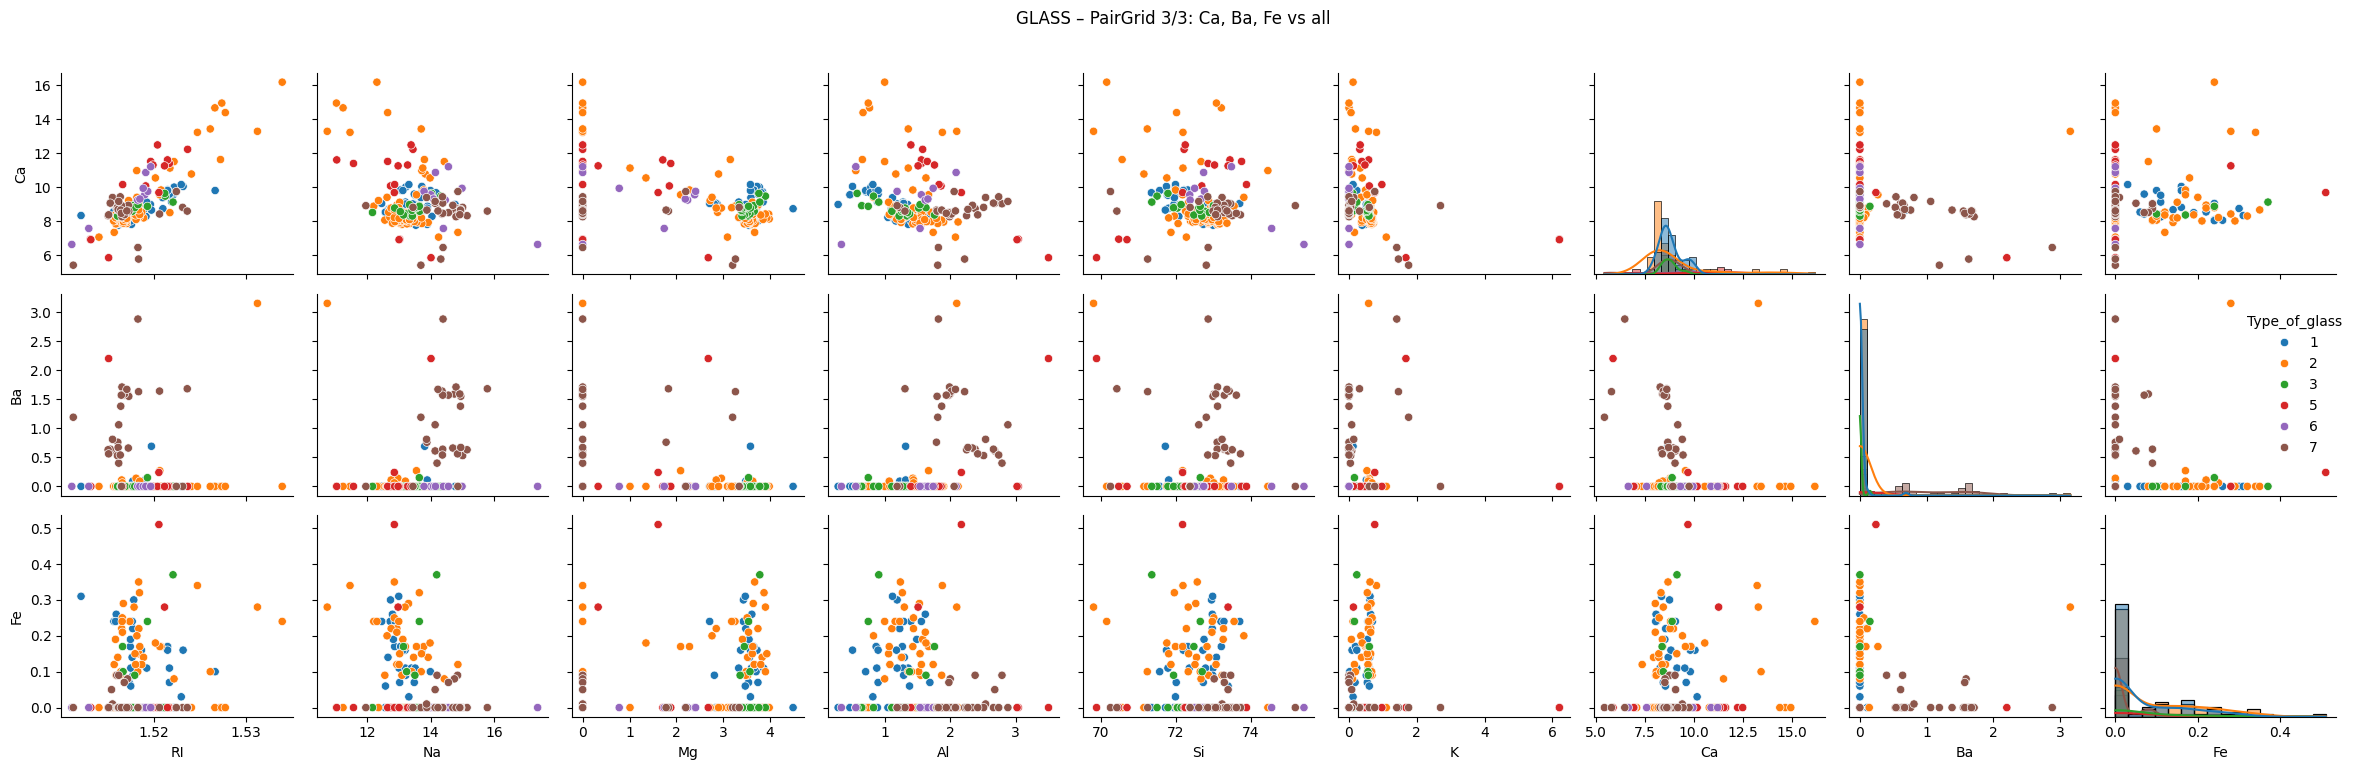

In [57]:
all_attrs = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

for i in range(0, len(all_attrs), 3):
    group = all_attrs[i:i+3]
    g = sns.PairGrid(df_glass, hue='Type_of_glass',
                     x_vars=all_attrs,
                     y_vars=group,
                     palette='tab10')
    g.map_diag(sns.histplot, kde=True)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()
    plt.suptitle(f'GLASS – PairGrid {i//3+1}/3: {", ".join(group)} vs all', y=1.02)
    plt.tight_layout()
    plt.show()

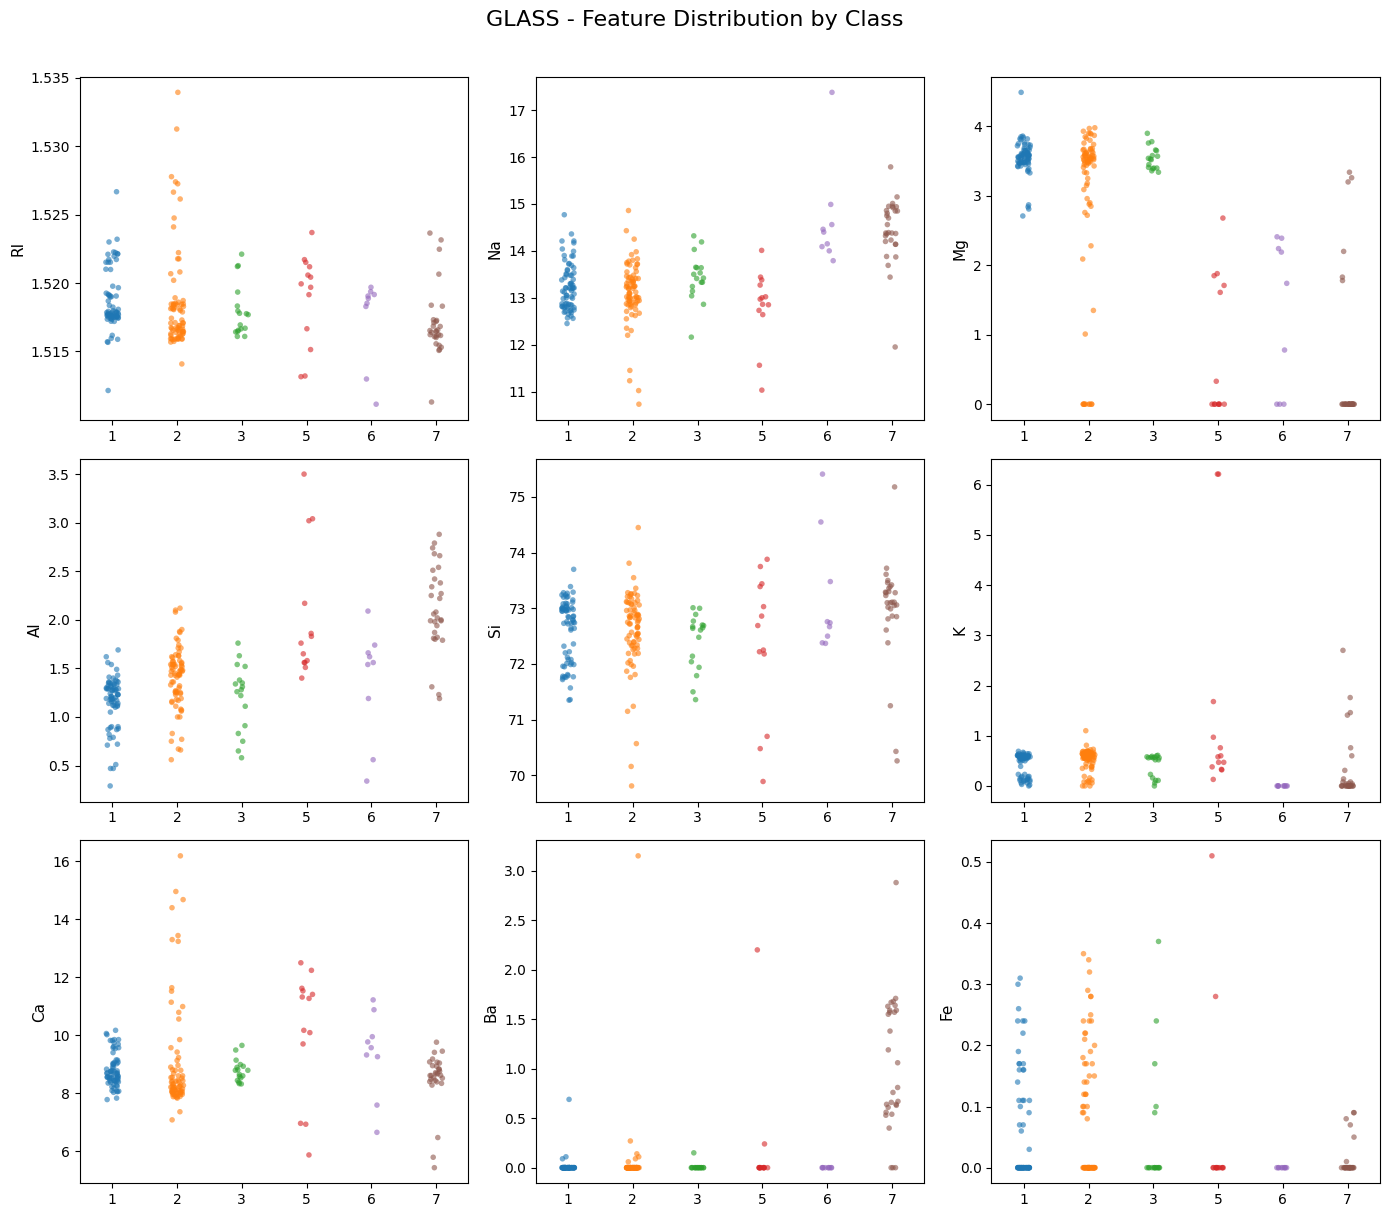

In [63]:
feature_cols_glass = X_glass.columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(feature_cols_glass) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
fig.suptitle('GLASS - Feature Distribution by Class', fontsize=16, y=1.01)
axes = axes.flatten()

for idx, feature in enumerate(feature_cols_glass):
    sns.stripplot(
        data=df_glass,
        x='Type_of_glass',
        y=feature,
        hue='Type_of_glass',
        ax=axes[idx],
        palette='tab10',
        alpha=0.6,
        size=4,
        legend=False,
    )
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].tick_params(axis='x', rotation=0)

for ax in axes[len(feature_cols_glass):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_32376/2603763481.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


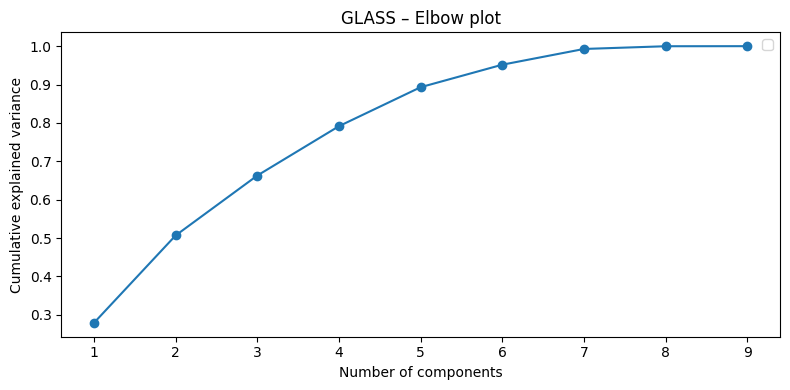

In [58]:

scaler_glass = StandardScaler()
X_glass_scaled = scaler_glass.fit_transform(X_glass)

pca_full = PCA()
pca_full.fit(X_glass_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('GLASS – Elbow plot')
plt.legend()
plt.tight_layout()
plt.show()

Widzimy, ze przy zmniejszemu PCA do 2 cech, zachowujemy tylko ok.50% wariancji, natomiast przy 4 cechach już ok. 80%, co pozwala nam na redukcję wymiaru bez utraty zbyt dużej ilości informacji, a jednocześnie ułatwia wizualizację.

In [59]:
pca_glass_4 = PCA(n_components=4)
X_glass_pca_4 = pca_glass_4.fit_transform(X_glass_scaled)

print(f"PC1 explains: {pca_glass_4.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca_glass_4.explained_variance_ratio_[1]:.2%} of variance")
print(f"PC3 explains: {pca_glass_4.explained_variance_ratio_[2]:.2%} of variance")
print(f"PC4 explains: {pca_glass_4.explained_variance_ratio_[3]:.2%} of variance")
print(f"Total: {sum(pca_glass_4.explained_variance_ratio_):.2%} of variance kept")

components_df_glass_4 = pd.DataFrame(
    pca_glass_4.components_,
    columns=X_glass.columns,
    index=['PC1', 'PC2', 'PC3', 'PC4']
)
print(components_df_glass_4)

PC1 explains: 27.90% of variance
PC2 explains: 22.78% of variance
PC3 explains: 15.61% of variance
PC4 explains: 12.87% of variance
Total: 79.15% of variance kept
           RI        Na        Mg        Al        Si         K        Ca  \
PC1  0.545177 -0.258126  0.110881 -0.428709 -0.228836 -0.219344  0.492306   
PC2 -0.285683 -0.270350  0.593558 -0.295212  0.155099  0.153970 -0.345380   
PC3  0.086911 -0.384920  0.008418  0.329237 -0.458709  0.662574 -0.000985   
PC4 -0.147381 -0.491242 -0.378786  0.137506  0.652538  0.038535  0.276443   

           Ba        Fe  
PC1 -0.250375  0.185842  
PC2 -0.484702  0.062039  
PC3  0.074055  0.284451  
PC4 -0.133175  0.230492  


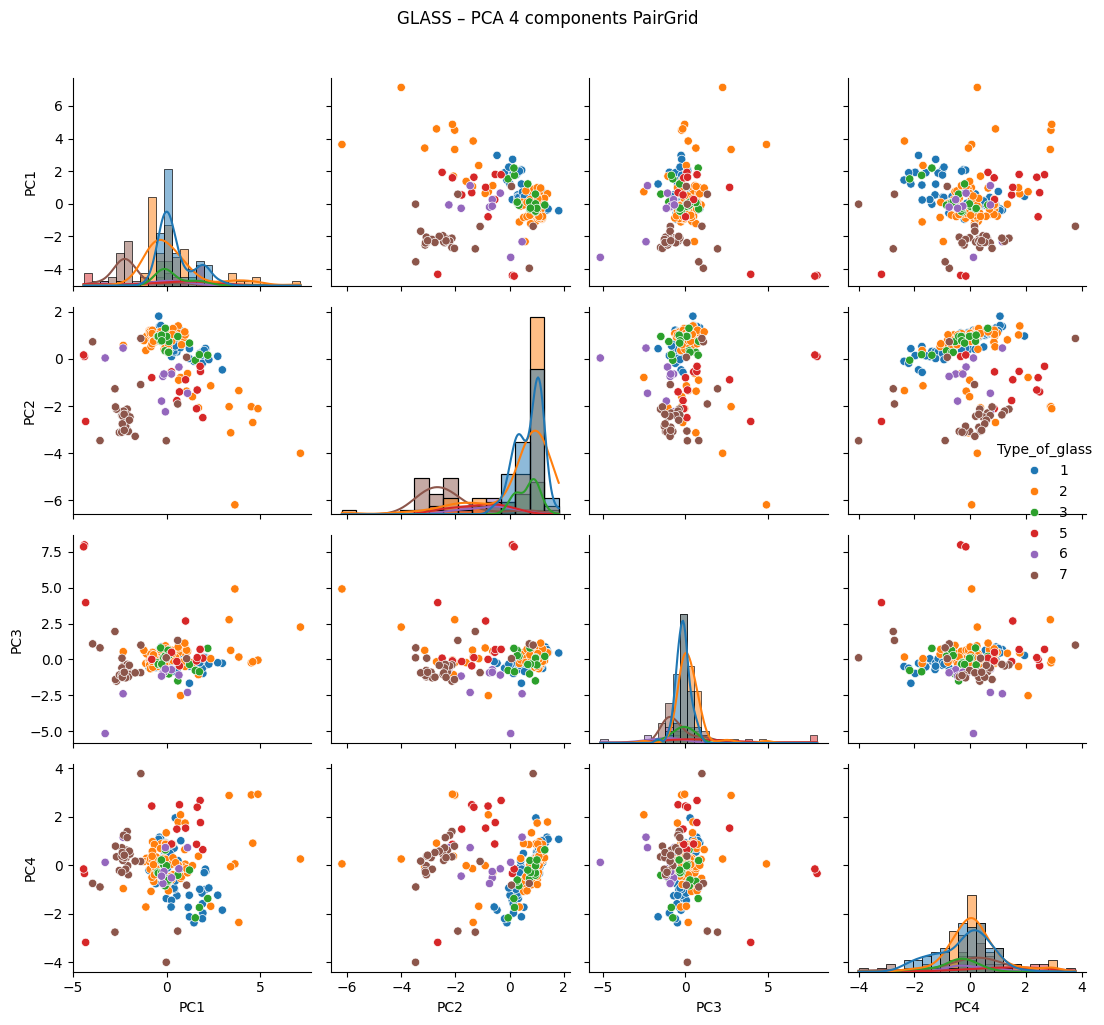

In [60]:
df_pca_glass_4 = pd.DataFrame(X_glass_pca_4, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca_glass_4['Type_of_glass'] = y_glass.values.ravel()

g = sns.PairGrid(df_pca_glass_4, hue='Type_of_glass', palette='tab10')
g.map_diag(sns.histplot, kde=True)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.suptitle('GLASS – PCA 4 components PairGrid', y=1.02)
plt.tight_layout()
plt.show()

In [61]:
pca_glass = PCA(n_components=2)
X_glass_pca = pca_glass.fit_transform(X_glass_scaled)

print(f"PC1 explains: {pca_glass.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca_glass.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total: {sum(pca_glass.explained_variance_ratio_):.2%} of variance kept")

components_df = pd.DataFrame(
    pca_glass.components_,
    columns=X_glass.columns,
    index=['PC1', 'PC2']
)
print(components_df)

PC1 explains: 27.90% of variance
PC2 explains: 22.78% of variance
Total: 50.68% of variance kept
           RI        Na        Mg        Al        Si         K        Ca  \
PC1  0.545177 -0.258126  0.110881 -0.428709 -0.228836 -0.219344  0.492306   
PC2 -0.285683 -0.270350  0.593558 -0.295212  0.155099  0.153970 -0.345380   

           Ba        Fe  
PC1 -0.250375  0.185842  
PC2 -0.484702  0.062039  


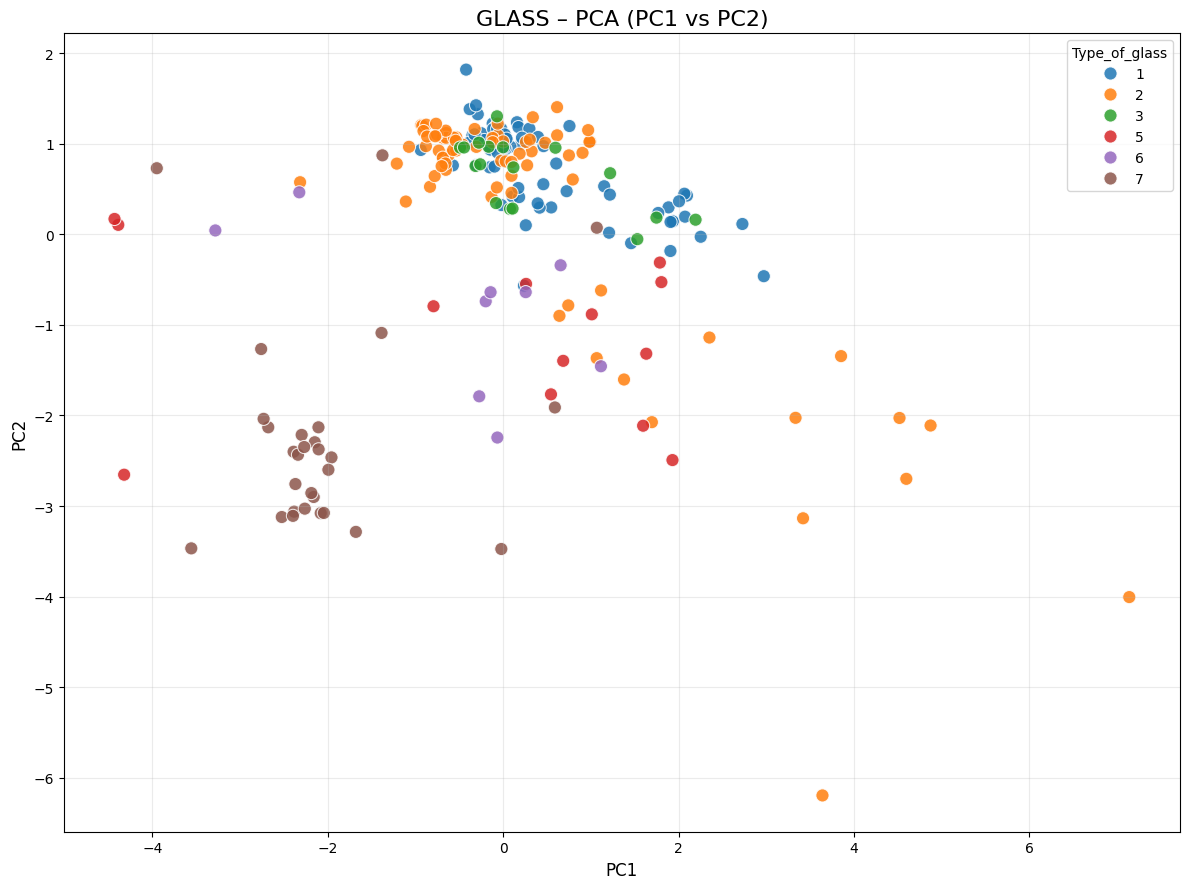

In [15]:
df_pca_glass = pd.DataFrame(X_glass_pca, columns=['PC1', 'PC2'])
df_pca_glass['Type_of_glass'] = y_glass.values.ravel()

plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=df_pca_glass,
    x='PC1',
    y='PC2',
    hue='Type_of_glass',
    s=90,
    alpha=0.85,
    palette='tab10'
)

plt.title('GLASS – PCA (PC1 vs PC2)', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend(title='Type_of_glass', loc='best')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

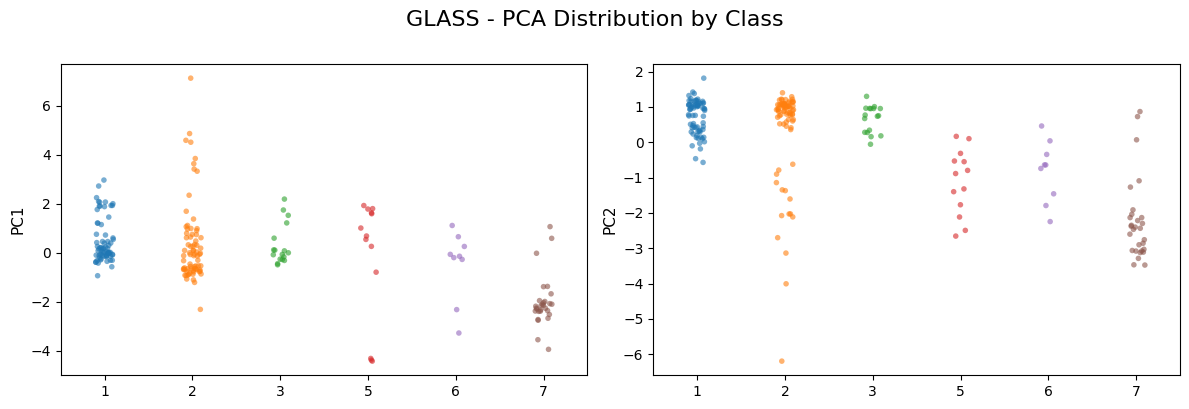

In [16]:
feature_cols_pca_glass = ['PC1', 'PC2']
n_cols = 2
n_rows = int(np.ceil(len(feature_cols_pca_glass) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
fig.suptitle('GLASS - PCA Distribution by Class', fontsize=16, y=1.01)
axes = np.array(axes).flatten()

for idx, feature in enumerate(feature_cols_pca_glass):
    sns.stripplot(
        data=df_pca_glass,
        x='Type_of_glass',
        y=feature,
        hue='Type_of_glass',
        ax=axes[idx],
        palette='tab10',
        alpha=0.6,
        size=4,
        legend=False
    )
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].tick_params(axis='x', rotation=0)

for ax in axes[len(feature_cols_pca_glass):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()